# Notebook 05 — ROM Prediction

 Online prediction interface. Given any $(k^*, S^*)$ within the training range and any user-defined rate schedule $q(t)$, produce the full spatial pressure field and BHP time series without running MRST.



---

## Steps

1. Interpolate $\hat{A}^*, \hat{B}^*, \hat{C}^*$ at $(\log_{10} k^*, S^*)$ using the saved RBF interpolants
2. Enforce stability: shift $\hat{A}^*$ if any eigenvalue has positive real part
3. Integrate the $n$-dimensional reduced ODE with implicit Euler
4. Reconstruct: $p(t) = p_{\mathrm{init}} + V_n\,\tilde{x}(t)$, $\;$ BHP$(t) = p_{\mathrm{init}} + \hat{C}^*\tilde{x}(t)$


---

## Rate schedule

```python
rate_schedule = [
    (0,    900),    # from t=0     : 900 STB/d
    (1000, 500),    # from t=1000 hr: 500 STB/d
    (3000,   0),    # from t=3000 hr: shut-in
]
```

---

## Interpret results

| Diagnostic | WBS (early) | MTR (middle) | BDF (late) |
|---|---|---|---|
| BHP vs log(t) | Flat or slight drop | Straight line slope $m$ | Accelerating decline |
| Log-log $\Delta p$ | Rising, slope 1 | Gentle rise | Steep rise |
| Bourdet derivative | Rising, slope 1 | Flat at $dp' = 70.6\,q\mu B_o / kh$ | Rising above flat |
| Pressure map | Uniform (reservoir intact) | Cone widening | Entire field depleting |

> **Note on early-time offset (t < 0.01 hr):** During WBS, BHP is governed by the wellbore capacitance equation, not the reservoir state. The ROM does not model the wellbore — the offset in the first 1–2 log-cycles is a known physical limitation, not a code error. All PTA interpretation uses data after WBS ends.

---
## 0. Imports, paths, and global style

In [1]:
import json
import pickle
import time
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path

# ── Journal-quality global style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.size'         : 10,
    'axes.labelsize'    : 10,
    'axes.titlesize'    : 10,
    'axes.titleweight'  : 'bold',
    'legend.fontsize'   : 8,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.constrained_layout.use': True,
})

# ── Paths — unchanged from all previous notebooks ─────────────────────────
BASIS_DIR   = Path('../rom/basis_CO')
INTERP_DIR  = Path('../rom/interpolants_CO')
RESULTS_DIR = Path('../results/predictions')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

P_INIT   = 4500.0
NX, NY   = 50, 50
T_END_HR = 5000.0
N_STEPS  = 350

# ── Load ROM components ────────────────────────────────────────────────────
Vn = np.load(BASIS_DIR / 'Vn.npy')
n  = Vn.shape[1]

with open(INTERP_DIR / 'A_hat_interp.pkl', 'rb') as f:
    A_pkg = pickle.load(f)
with open(INTERP_DIR / 'B_hat_interp.pkl', 'rb') as f:
    B_pkg = pickle.load(f)
with open(INTERP_DIR / 'C_hat_interp.pkl', 'rb') as f:
    C_pkg = pickle.load(f)

A_interps, A_shape = A_pkg['interps'], A_pkg['shape']
B_interps, B_shape = B_pkg['interps'], B_pkg['shape']
C_interps, C_shape = C_pkg['interps'], C_pkg['shape']

with open(INTERP_DIR / 'interp_metadata.json') as f:
    interp_meta = json.load(f)

print(f'ROM loaded  |  n = {n} modes')
print(f'Parameter range : k = [{min(interp_meta["k_grid"])}, {max(interp_meta["k_grid"])}] mD')
print(f'                  S = [{min(interp_meta["S_grid"])}, {max(interp_meta["S_grid"])}]')

ROM loaded  |  n = 6 modes
Parameter range : k = [5, 500] mD
                  S = [0, 15]


---
## 1. Utility functions

fixed: `dt` is in **hours** throughout to match the operator units from NB02.

In [2]:
def make_time_grid(t_start_hr=0.001, t_end_hr=T_END_HR, n_steps=N_STEPS):
    return np.logspace(np.log10(t_start_hr), np.log10(t_end_hr), n_steps)


def schedule_to_qvec(rate_schedule, t_hr):
    q = np.full(len(t_hr), float(rate_schedule[0][1]))
    for i in range(1, len(rate_schedule)):
        t_change, r = rate_schedule[i]
        q[t_hr >= t_change] = float(r)
    return q

def wbs_kernel(tau_hr, t_wbs_hr, Bo, C_bbl_psi):
    if t_wbs_hr <= 0 or C_bbl_psi == 0:
        return np.zeros_like(tau_hr)
    magnitude = Bo / (24.0 * C_bbl_psi)
    return magnitude * tau_hr * np.exp(-tau_hr / t_wbs_hr)


def compute_wbs_correction(t_hr, rate_schedule, k_mD, S_skin,
                            C_bbl_psi, Bo=1.15, h_ft=150):
    if C_bbl_psi == 0:
        return np.zeros(len(t_hr))
    kh    = k_mD * h_ft
    t_wbs = 170000 * C_bbl_psi * np.exp(2 * S_skin) / kh
    q_prev = 0.0
    dp_wbs = np.zeros(len(t_hr))
    for tc, rv in rate_schedule:
        dq     = float(rv) - q_prev
        tau    = t_hr - float(tc)
        active = tau > 0
        dp_wbs[active] += dq * wbs_kernel(tau[active], t_wbs, Bo, C_bbl_psi)
        q_prev = float(rv)
    return np.abs(dp_wbs)



def predict(k_star, s_star, rate_schedule,
            display_C=0.003,        # WBS coefficient for display
            Bo=1.15, h_ft=150,
            t_start_hr=0.001, t_end_hr=T_END_HR, n_steps=N_STEPS):

    assert 5 <= k_star <= 500
    assert 0 <= s_star <= 15

    t0   = time.perf_counter()
    t_hr = make_time_grid(t_start_hr, t_end_hr, n_steps)
    q    = schedule_to_qvec(rate_schedule, t_hr)

    pt    = np.array([[np.log10(k_star), s_star]])
    A_hat = np.array([f(pt)[0] for f in A_interps]).reshape(A_shape)
    B_hat = np.array([f(pt)[0] for f in B_interps]).reshape(B_shape)
    C_hat = np.array([f(pt)[0] for f in C_interps]).reshape(C_shape)

    eigvals    = np.linalg.eigvals(A_hat)
    max_real   = float(np.max(eigvals.real))
    stabilised = False
    if max_real >= 0:
        A_hat      = A_hat - (max_real + 1e-6) * np.eye(n)
        stabilised = True

    K     = len(t_hr)
    dt    = np.diff(t_hr, prepend=0.0)
    dt[0] = t_hr[0]
    In    = np.eye(n)
    X_rom = np.zeros((K, n))
    Y_rom = np.zeros(K)
    xk    = np.zeros(n)

    for j in range(K):
        dtj = dt[j]
        rhs = xk + dtj * (B_hat.ravel() * q[j])
        xk  = np.linalg.solve(In - dtj * A_hat, rhs)
        X_rom[j] = xk
        Y_rom[j] = float((C_hat @ xk).item())

    # Part 1 — reservoir
    bhp_reservoir = P_INIT + Y_rom
    dp_reservoir  = P_INIT - bhp_reservoir

    # Part 2 — analytical WBS
    dp_wbs  = compute_wbs_correction(t_hr, rate_schedule,
                                      k_star, s_star, display_C, Bo, h_ft)

    # Superposition
    dp_total  = dp_reservoir + dp_wbs
    bhp_total = P_INIT - dp_total
    p_field   = P_INIT + Vn @ X_rom.T
    kh        = k_star * h_ft
    t_wbs_val = (170000 * display_C * np.exp(2 * s_star) / kh
                 if display_C > 0 else 0.0)

    return dict(
        t_hr          = t_hr,
        bhp_psia      = bhp_total,
        bhp_reservoir = bhp_reservoir,
        dp_psi        = dp_total,
        dp_reservoir  = dp_reservoir,
        dp_wbs        = dp_wbs,
        p_field       = p_field,
        q_vec         = q,
        stable        = True,
        stabilised    = stabilised,
        t_wbs_hr      = t_wbs_val,
        wall_ms       = (time.perf_counter() - t0) * 1000,
    )


def bourdet_derivative(t_hr, dp_psi, L=0.2):
    """Bourdet pressure derivative dp/d(ln t) with L-smoothing."""
    ln_t  = np.log(t_hr)
    dp_d  = np.full_like(dp_psi, np.nan)
    for i in range(1, len(t_hr) - 1):
        il = i - 1
        while il > 0 and (ln_t[i] - ln_t[il]) < L:
            il -= 1
        ir = i + 1
        while ir < len(t_hr) - 1 and (ln_t[ir] - ln_t[i]) < L:
            ir += 1
        dl = ln_t[i] - ln_t[il]
        dr = ln_t[ir] - ln_t[i]
        if dl > 0 and dr > 0:
            dp_d[i] = ((dp_psi[i] - dp_psi[il]) / dl * dr +
                       (dp_psi[ir] - dp_psi[i]) / dr * dl) / (dl + dr)
    mask = np.isfinite(dp_d) & (dp_d > 0) & (dp_psi > 0)
    return t_hr[mask], dp_psi[mask], dp_d[mask]


def pressure_map_panel(ax, p_field, snap_idx, t_hr, vmin, vmax, label=''):
    """Plot one pressure map panel with consistent colorscale."""
    im = ax.imshow(p_field[:, snap_idx].reshape(NY, NX),
                   origin='lower', cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                   aspect='equal')
    ax.plot(NX // 2, NY // 2, 'w*', ms=9, markeredgecolor='k',
            markeredgewidth=0.5, zorder=5)
    ax.set_title(f't = {t_hr[snap_idx]:.1f} hr  ({label})', pad=4)
    ax.set_xlabel('Grid column')
    ax.set_ylabel('Grid row')
    ax.tick_params(labelsize=8)
    return im


print('Functions defined.')

Functions defined.


---
## 2. Example 1 — Constant-rate drawdown

**Simulation Setup:** k = 20 mD, S = 2, constant q = 800 STB/d — close to the original MRST baseline.

**Results:**
- BHP declines in three distinct phases on a semi-log scale
- Log-log Bourdet derivative: unit-slope rise (WBS) → flat plateau (MTR) → rising again (BDF)
- Flat Bourdet level $dp' = 70.6 \times 800 \times 1.2 \times 1.15 / (20 \times 150) \approx 25.8$ psi
- Pressure maps: near-uniform early, then widening cone, then full-field depletion

Wall time  : 12.3 ms
Stabilised : False
BHP range  : -39518.7 – 4487.0 psia
Max Δp     : 44018.7 psi


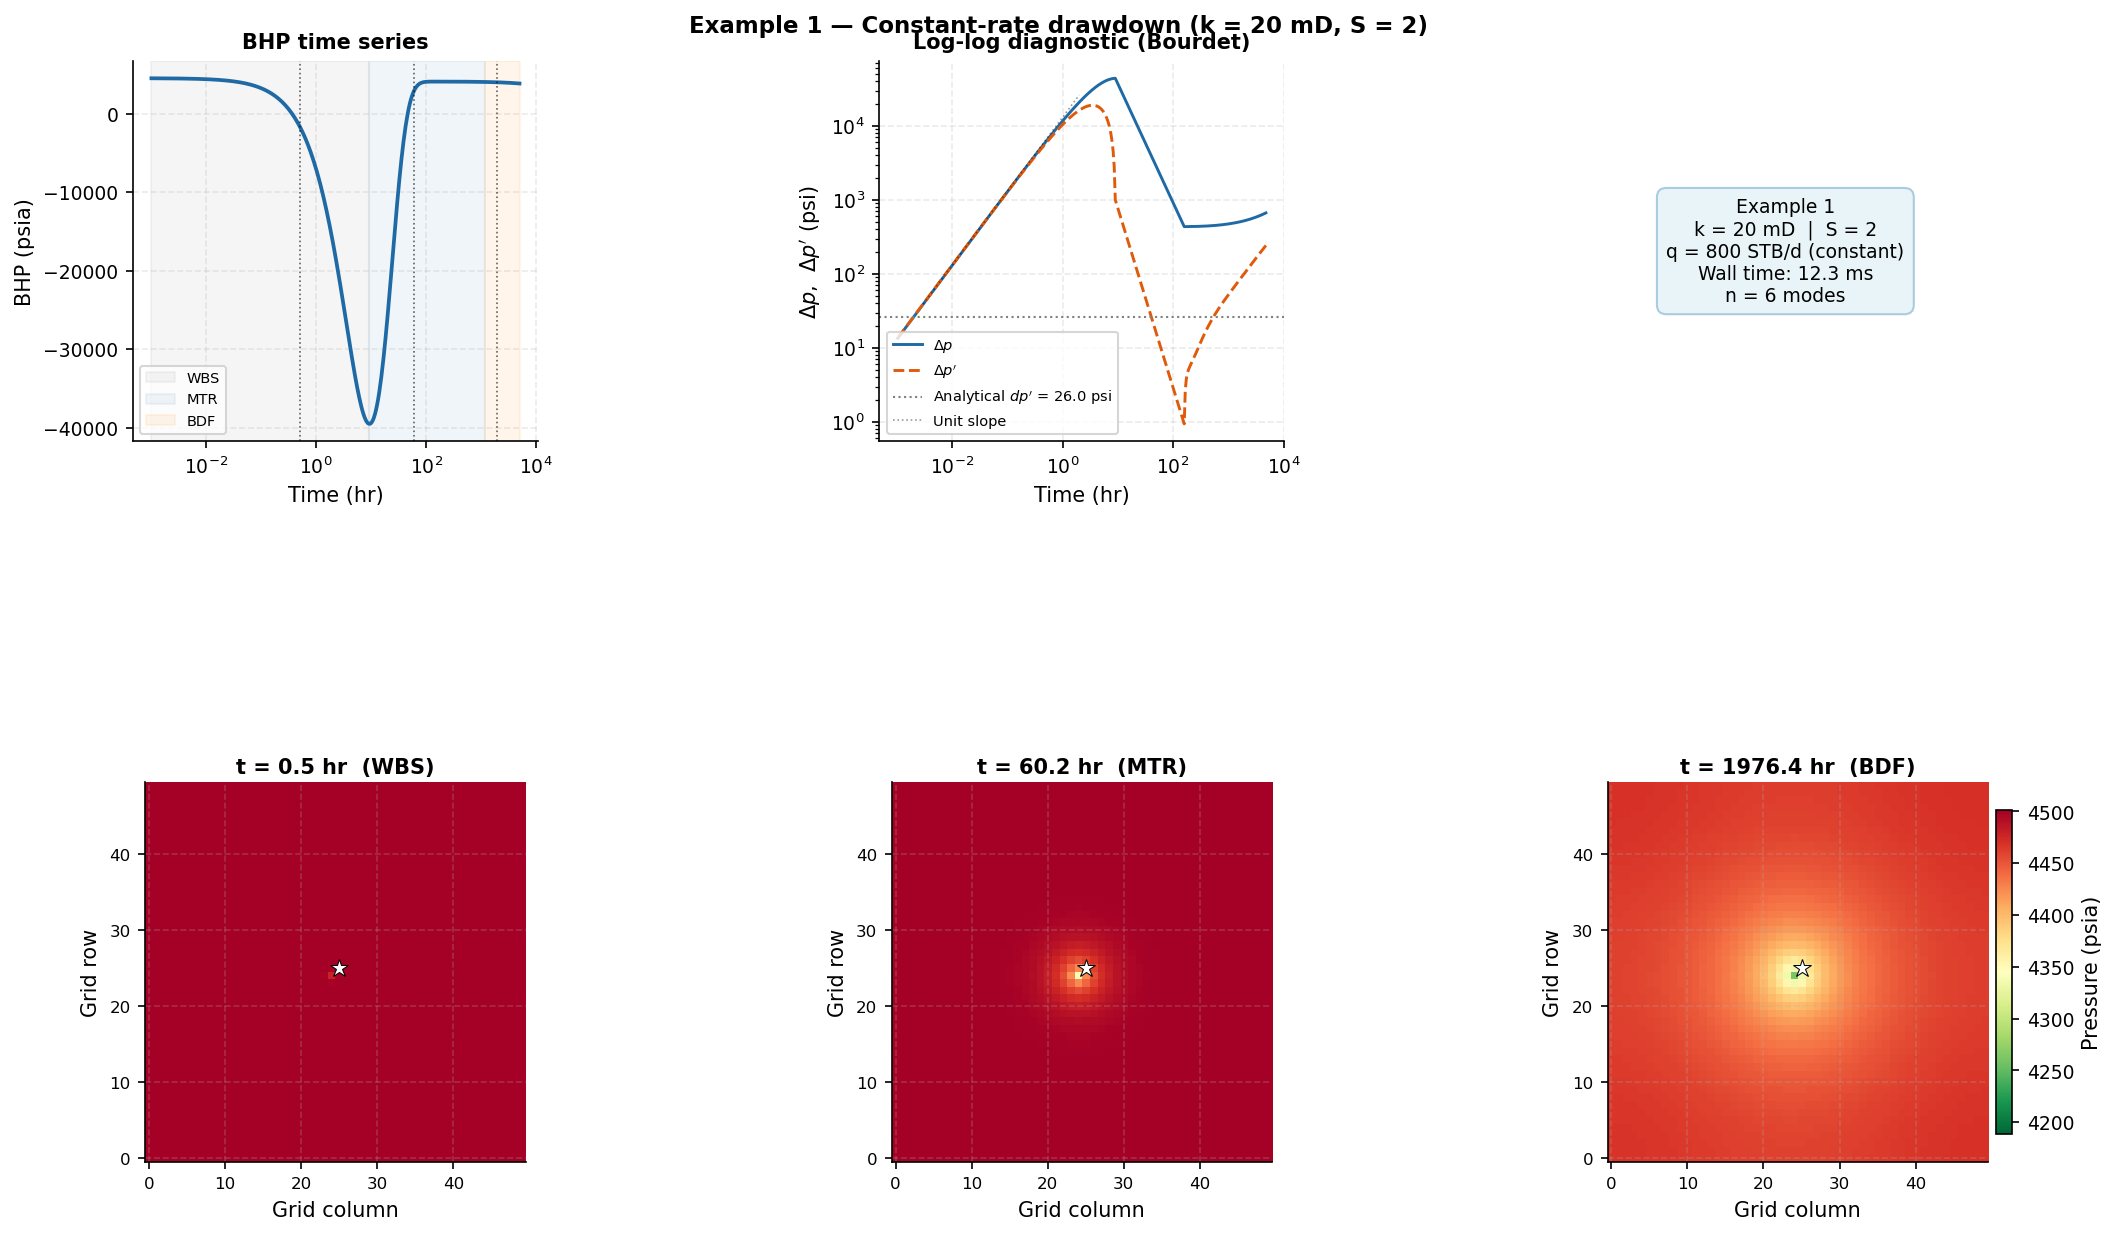

Figure saved.


In [3]:
r1 = predict(k_star=20, s_star=2, rate_schedule=[(0, 800)])
print(f'Wall time  : {r1["wall_ms"]:.1f} ms')
print(f'Stabilised : {r1["stabilised"]}')
print(f'BHP range  : {r1["bhp_psia"].min():.1f} – {r1["bhp_psia"].max():.1f} psia')
print(f'Max Δp     : {r1["dp_psi"].max():.1f} psi')

t1, dp1, bd1 = bourdet_derivative(r1['t_hr'], r1['dp_psi'])

# Snapshot indices: WBS, MTR, BDF
snap_wbs = np.argmin(np.abs(r1['t_hr'] - 0.5))
snap_mtr = np.argmin(np.abs(r1['t_hr'] - 60))
snap_bdf = np.argmin(np.abs(r1['t_hr'] - 2000))
snaps    = [(snap_wbs, 'WBS'), (snap_mtr, 'MTR'), (snap_bdf, 'BDF')]

p_min1 = r1['p_field'].min()
p_max1 = r1['p_field'].max()

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── BHP vs time ──────────────────────────────────────────────────────────
ax_bhp = fig.add_subplot(gs[0, 0])
ax_bhp.semilogx(r1['t_hr'], r1['bhp_psia'], lw=1.8, color='#1f6aa5')
ax_bhp.axvspan(r1['t_hr'][0], 9.3,   alpha=0.08, color='gray',       label='WBS')
ax_bhp.axvspan(9.3,           1189,  alpha=0.08, color='steelblue',  label='MTR')
ax_bhp.axvspan(1189,          5000,  alpha=0.08, color='darkorange', label='BDF')
for s_idx, s_lbl in snaps:
    ax_bhp.axvline(r1['t_hr'][s_idx], color='k', ls=':', lw=0.8, alpha=0.6)
ax_bhp.set_xlabel('Time (hr)')
ax_bhp.set_ylabel('BHP (psia)')
ax_bhp.set_title('BHP time series')
ax_bhp.legend(loc='lower left', fontsize=7)

# ── Log-log Bourdet ──────────────────────────────────────────────────────
ax_ll = fig.add_subplot(gs[0, 1])
ax_ll.loglog(t1, dp1,  lw=1.4, color='#1f6aa5',  label=r'$\Delta p$')
ax_ll.loglog(t1, bd1,  lw=1.4, color='#e05a0c',  ls='--', label=r"$\Delta p'$")
dp_prime_an = 70.6 * 800 * 1.2 * 1.15 / (20 * 150)
ax_ll.axhline(dp_prime_an, color='gray', ls=':', lw=1,
              label=f"Analytical $dp'$ = {dp_prime_an:.1f} psi")
# Unit-slope reference
t_ref = np.array([0.003, 2])
ax_ll.loglog(t_ref, t_ref * bd1[2] / t1[2], 'k:', lw=0.8, alpha=0.4, label='Unit slope')
ax_ll.set_xlabel('Time (hr)')
ax_ll.set_ylabel('$\\Delta p$,  $\\Delta p\'$ (psi)')
ax_ll.set_title('Log-log diagnostic (Bourdet)')
ax_ll.legend(fontsize=7)

# ── Pressure maps ────────────────────────────────────────────────────────
for col, (s_idx, s_lbl) in enumerate(snaps):
    ax_m = fig.add_subplot(gs[1, col])
    im   = pressure_map_panel(ax_m, r1['p_field'], s_idx,
                               r1['t_hr'], p_min1, p_max1, s_lbl)
    if col == 2:
        plt.colorbar(im, ax=ax_m, label='Pressure (psia)', shrink=0.85, pad=0.02)

# Add label for the row
ax_ll_top = fig.add_subplot(gs[0, 2])
ax_ll_top.axis('off')
ax_ll_top.text(0.5, 0.5,
    f'Example 1\nk = 20 mD  |  S = 2\nq = 800 STB/d (constant)\n'
    f'Wall time: {r1["wall_ms"]:.1f} ms\nn = {n} modes',
    ha='center', va='center', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f4f8', edgecolor='#aacce0'))

fig.suptitle('Example 1 — Constant-rate drawdown (k = 20 mD, S = 2)',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig(RESULTS_DIR / 'example1_constant_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 3. Example 2 — Multi-step rate schedule

**simulation parameters:** k = 75 mD, S = 3 (off-grid — interpolated), three-period schedule: high rate → reduced rate → shut-in buildup.

**Expected results:**
- BHP declines during first period, responds to rate reduction at t = 1000 hr (slope change)
- During shut-in (t > 3000 hr) BHP rises monotonically toward $p_{\mathrm{init}}$ (buildup)
- Pressure maps: deepening cone during drawdown, uniform recovery during buildup
- The rate changes appear as vertical markers on the BHP plot

Wall time  : 5.5 ms  |  Stabilised: True
BHP range  : -103246.5 – 4483.9 psia


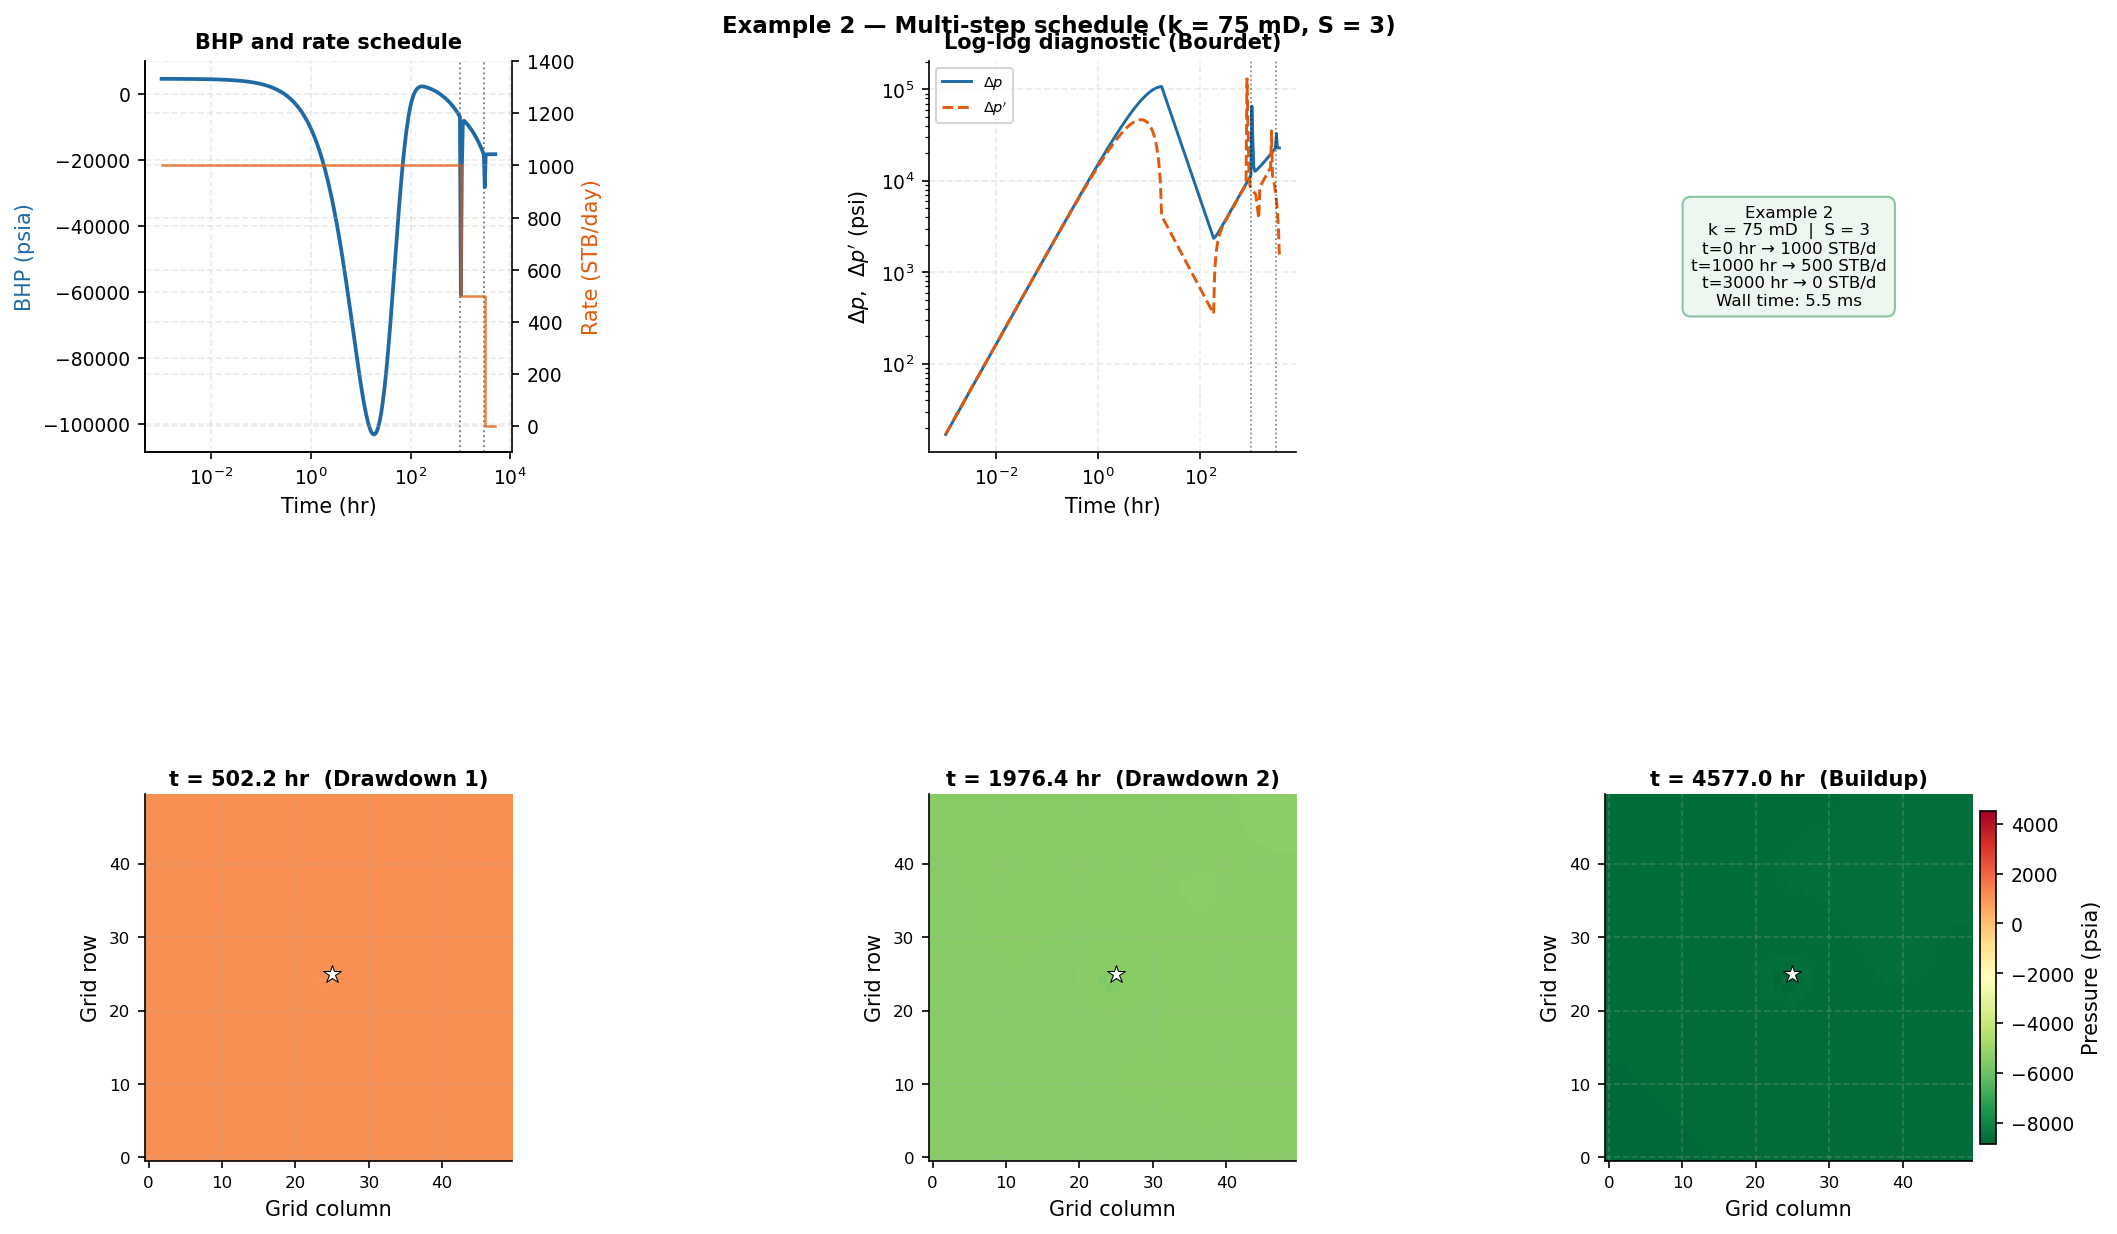

Figure saved.


In [4]:
# ── USER INPUTS ───────────────────────────────────────────────────────────
k_query = 75
S_query = 3
rate_schedule = [
    (0,    1000),
    (1000,  500),
    (3000,    0),
]
# ─────────────────────────────────────────────────────────────────────────

r2 = predict(k_query, S_query, rate_schedule)
print(f'Wall time  : {r2["wall_ms"]:.1f} ms  |  Stabilised: {r2["stabilised"]}')
print(f'BHP range  : {r2["bhp_psia"].min():.1f} – {r2["bhp_psia"].max():.1f} psia')

dp2_pos = np.clip(r2['dp_psi'], 1e-3, None)
t2, dp2_brd, bd2 = bourdet_derivative(r2['t_hr'], dp2_pos)

snap_dd1  = np.argmin(np.abs(r2['t_hr'] - 500))
snap_dd2  = np.argmin(np.abs(r2['t_hr'] - 2000))
snap_bu   = np.argmin(np.abs(r2['t_hr'] - 4500))
snaps2    = [(snap_dd1, 'Drawdown 1'), (snap_dd2, 'Drawdown 2'), (snap_bu, 'Buildup')]

p_min2 = r2['p_field'].min()
p_max2 = r2['p_field'].max()

rate_colors = {'Drawdown 1': '#1f6aa5', 'Drawdown 2': '#2c9c6a', 'Buildup': '#c0392b'}

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── BHP + rate ────────────────────────────────────────────────────────────
ax_bhp2 = fig.add_subplot(gs[0, 0])
ax_q2   = ax_bhp2.twinx()
ax_bhp2.semilogx(r2['t_hr'], r2['bhp_psia'], lw=1.8, color='#1f6aa5', zorder=3)
ax_q2.step(r2['t_hr'], r2['q_vec'], color='#e05a0c', lw=1.2,
           where='post', alpha=0.75, zorder=2)
for tc, _ in rate_schedule[1:]:
    ax_bhp2.axvline(tc, color='k', ls=':', lw=0.9, alpha=0.5)
ax_bhp2.set_xlabel('Time (hr)')
ax_bhp2.set_ylabel('BHP (psia)', color='#1f6aa5')
ax_q2.set_ylabel('Rate (STB/day)', color='#e05a0c')
ax_q2.set_ylim(-100, max(r2['q_vec']) * 1.4)
ax_bhp2.set_title('BHP and rate schedule')
ax_bhp2.spines['right'].set_visible(True)

# ── Log-log Bourdet ──────────────────────────────────────────────────────
ax_ll2 = fig.add_subplot(gs[0, 1])
ax_ll2.loglog(t2, dp2_brd, lw=1.4, color='#1f6aa5', label=r'$\Delta p$')
ax_ll2.loglog(t2, bd2,     lw=1.4, color='#e05a0c', ls='--', label=r"$\Delta p'$")
for tc, _ in rate_schedule[1:]:
    ax_ll2.axvline(tc, color='k', ls=':', lw=0.8, alpha=0.5)
ax_ll2.set_xlabel('Time (hr)')
ax_ll2.set_ylabel('$\\Delta p$,  $\\Delta p\'$ (psi)')
ax_ll2.set_title('Log-log diagnostic (Bourdet)')
ax_ll2.legend(fontsize=7)

# ── Pressure maps ────────────────────────────────────────────────────────
for col, (s_idx, s_lbl) in enumerate(snaps2):
    ax_m = fig.add_subplot(gs[1, col])
    im   = pressure_map_panel(ax_m, r2['p_field'], s_idx,
                               r2['t_hr'], p_min2, p_max2, s_lbl)
    if col == 2:
        plt.colorbar(im, ax=ax_m, label='Pressure (psia)', shrink=0.85, pad=0.02)

ax_info2 = fig.add_subplot(gs[0, 2])
ax_info2.axis('off')
sched_txt = '\n'.join([f't={tc} hr → {rv} STB/d' for tc, rv in rate_schedule])
ax_info2.text(0.5, 0.5,
    f'Example 2\nk = {k_query} mD  |  S = {S_query}\n{sched_txt}\n'
    f'Wall time: {r2["wall_ms"]:.1f} ms',
    ha='center', va='center', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#edf7f0', edgecolor='#8bc4a0'))

fig.suptitle(f'Example 2 — Multi-step schedule (k = {k_query} mD, S = {S_query})',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig(RESULTS_DIR / 'example2_multistep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 4. Example 3 — Low-permeability, high-skin case

**Simulation setup:** k = 10 mD, S = 10 — tight reservoir with significant skin damage. Constant q = 600 STB/d.

**Expected results:**
- WBS dominates a much longer early period (skin delays the onset of radial flow)
- MTR slope $m$ is large because kh is small (same q but less productive formation)
- Total drawdown is much larger than Example 1
- Pressure map shows a tight, steep cone near the well even at late time — skin concentrates the pressure drop near the wellbore

Wall time  : 6.8 ms  |  Stabilised: False
BHP range  : -47912262.7 – 4490.0 psia


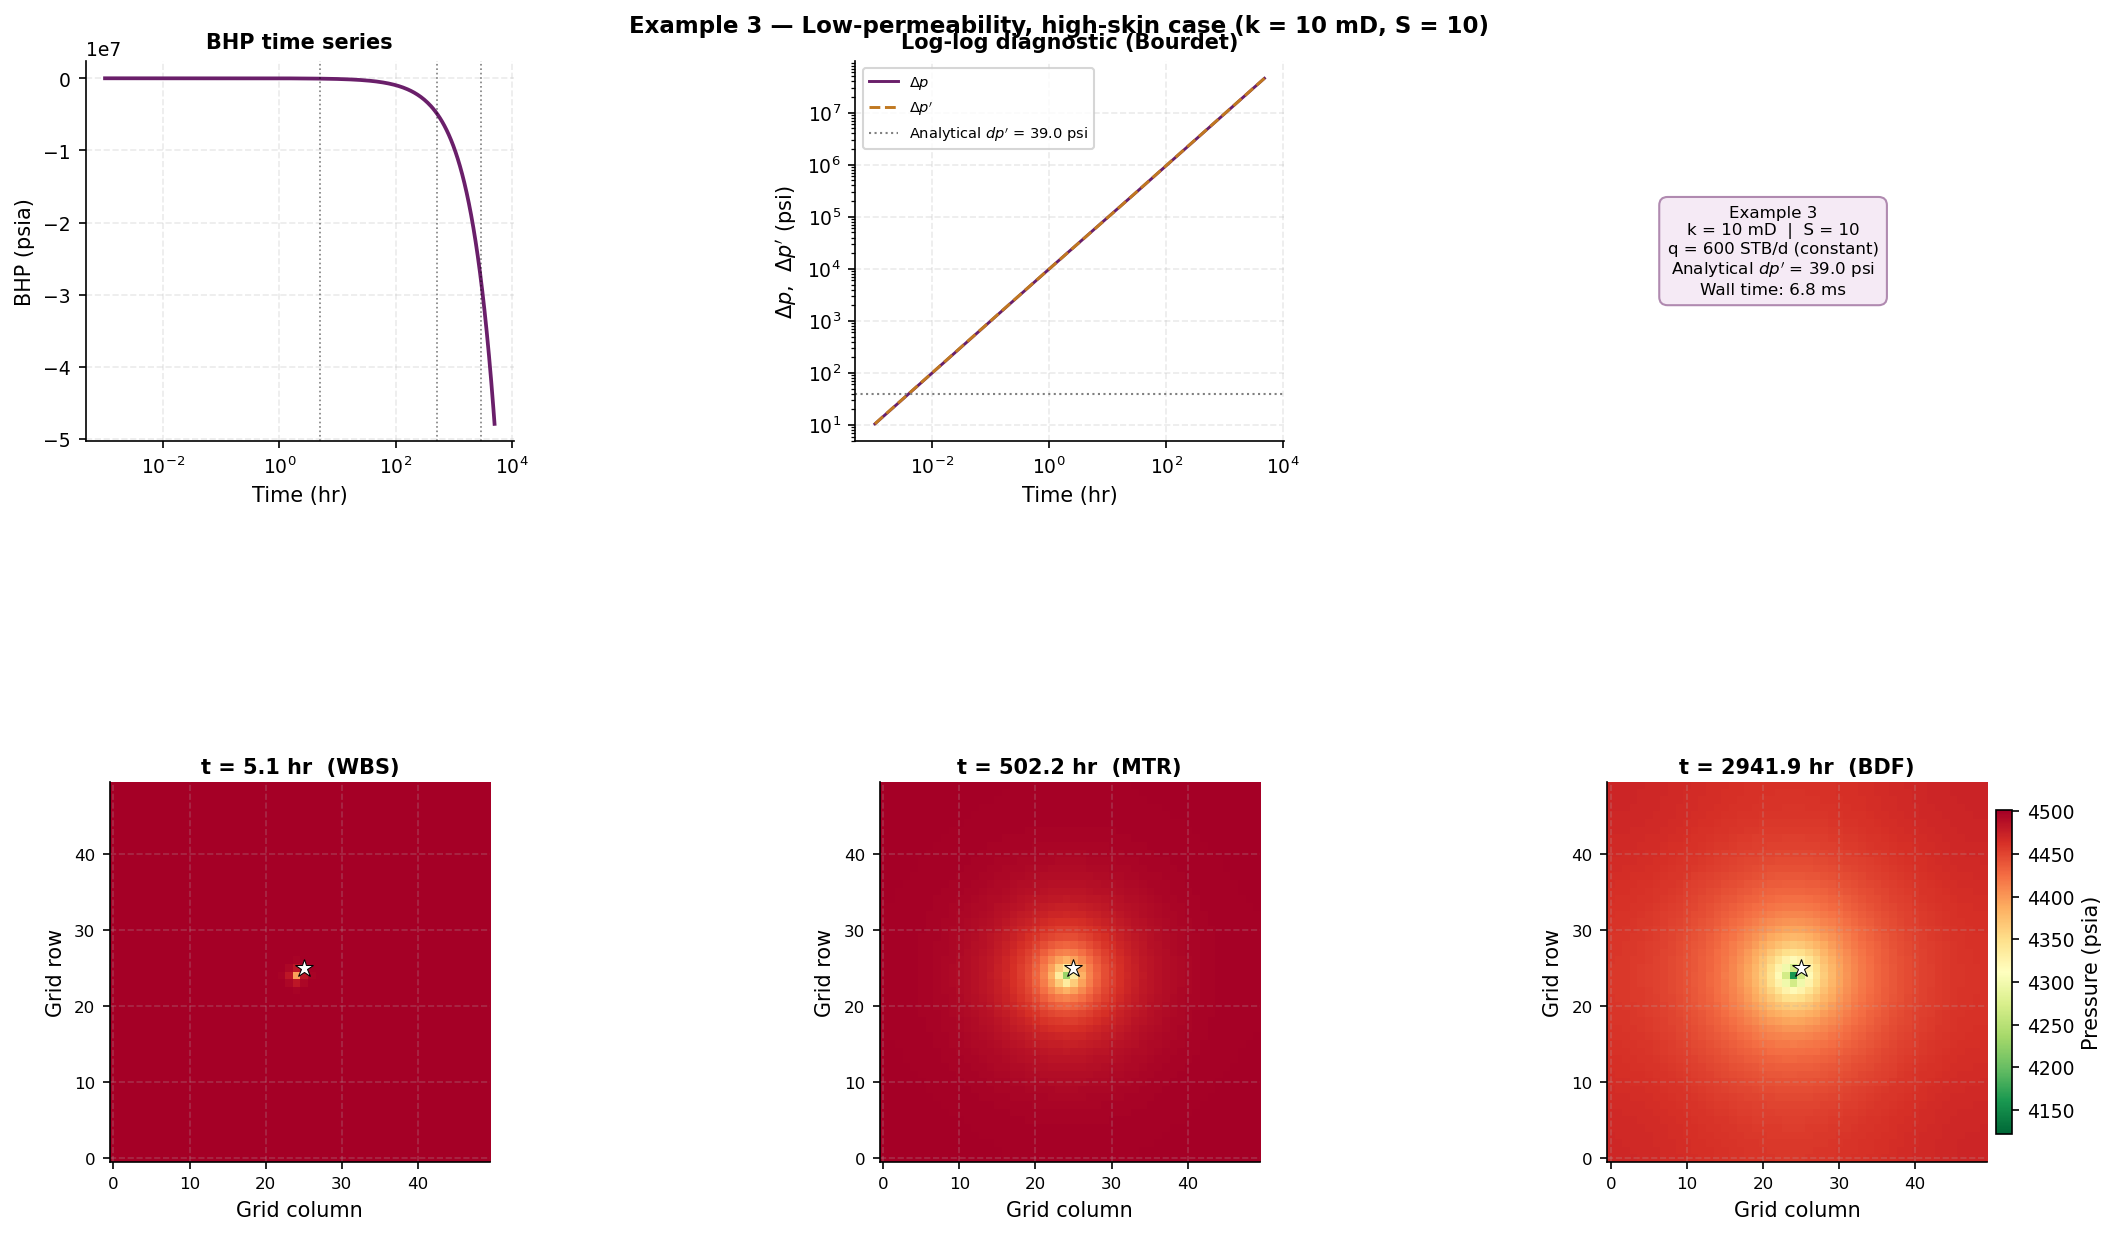

Figure saved.


In [5]:
r3 = predict(k_star=10, s_star=10, rate_schedule=[(0, 600)])
print(f'Wall time  : {r3["wall_ms"]:.1f} ms  |  Stabilised: {r3["stabilised"]}')
print(f'BHP range  : {r3["bhp_psia"].min():.1f} – {r3["bhp_psia"].max():.1f} psia')

dp3_pos = np.clip(r3['dp_psi'], 1e-3, None)
t3, dp3_brd, bd3 = bourdet_derivative(r3['t_hr'], dp3_pos)

dp_prime_ex3 = 70.6 * 600 * 1.2 * 1.15 / (10 * 150)

snap3_wbs = np.argmin(np.abs(r3['t_hr'] - 5))
snap3_mtr = np.argmin(np.abs(r3['t_hr'] - 500))
snap3_bdf = np.argmin(np.abs(r3['t_hr'] - 3000))
snaps3    = [(snap3_wbs, 'WBS'), (snap3_mtr, 'MTR'), (snap3_bdf, 'BDF')]

p_min3 = r3['p_field'].min()
p_max3 = r3['p_field'].max()

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_bhp3 = fig.add_subplot(gs[0, 0])
ax_bhp3.semilogx(r3['t_hr'], r3['bhp_psia'], lw=1.8, color='#6a1f6a')
ax_bhp3.set_xlabel('Time (hr)')
ax_bhp3.set_ylabel('BHP (psia)')
ax_bhp3.set_title('BHP time series')
for s_idx, _ in snaps3:
    ax_bhp3.axvline(r3['t_hr'][s_idx], color='k', ls=':', lw=0.8, alpha=0.5)

ax_ll3 = fig.add_subplot(gs[0, 1])
ax_ll3.loglog(t3, dp3_brd, lw=1.4, color='#6a1f6a',  label=r'$\Delta p$')
ax_ll3.loglog(t3, bd3,     lw=1.4, color='#c07820',  ls='--', label=r"$\Delta p'$")
ax_ll3.axhline(dp_prime_ex3, color='gray', ls=':', lw=1,
               label=f"Analytical $dp'$ = {dp_prime_ex3:.1f} psi")
ax_ll3.set_xlabel('Time (hr)')
ax_ll3.set_ylabel('$\\Delta p$,  $\\Delta p\'$ (psi)')
ax_ll3.set_title('Log-log diagnostic (Bourdet)')
ax_ll3.legend(fontsize=7)

for col, (s_idx, s_lbl) in enumerate(snaps3):
    ax_m = fig.add_subplot(gs[1, col])
    im   = pressure_map_panel(ax_m, r3['p_field'], s_idx,
                               r3['t_hr'], p_min3, p_max3, s_lbl)
    if col == 2:
        plt.colorbar(im, ax=ax_m, label='Pressure (psia)', shrink=0.85, pad=0.02)

ax_info3 = fig.add_subplot(gs[0, 2])
ax_info3.axis('off')
ax_info3.text(0.5, 0.5,
    f'Example 3\nk = 10 mD  |  S = 10\nq = 600 STB/d (constant)\n'
    f'Analytical $dp\'$ = {dp_prime_ex3:.1f} psi\n'
    f'Wall time: {r3["wall_ms"]:.1f} ms',
    ha='center', va='center', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5eaf5', edgecolor='#b08ab0'))

fig.suptitle('Example 3 — Low-permeability, high-skin case (k = 10 mD, S = 10)',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig(RESULTS_DIR / 'example3_low_k_high_skin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 5. Parametric sweep — effect of permeability

Seven k values at fixed S = 5, constant 800 STB/d. The sweep is split into four separate panels to avoid overplotting:

- **Panel A:** BHP on a semi-log scale — spacing between curves indicates k sensitivity
- **Panel B:** Drawdown Δp on a log-log scale — flat WBS region duration shortens with k
- **Panel C:** Bourdet derivative — flat level $dp' \propto 1/k$; lower k → higher plateau
- **Panel D:** BDF onset time vs k — time when Bourdet derivative rises above flat level

7 predictions in 50 ms  (7.1 ms each)


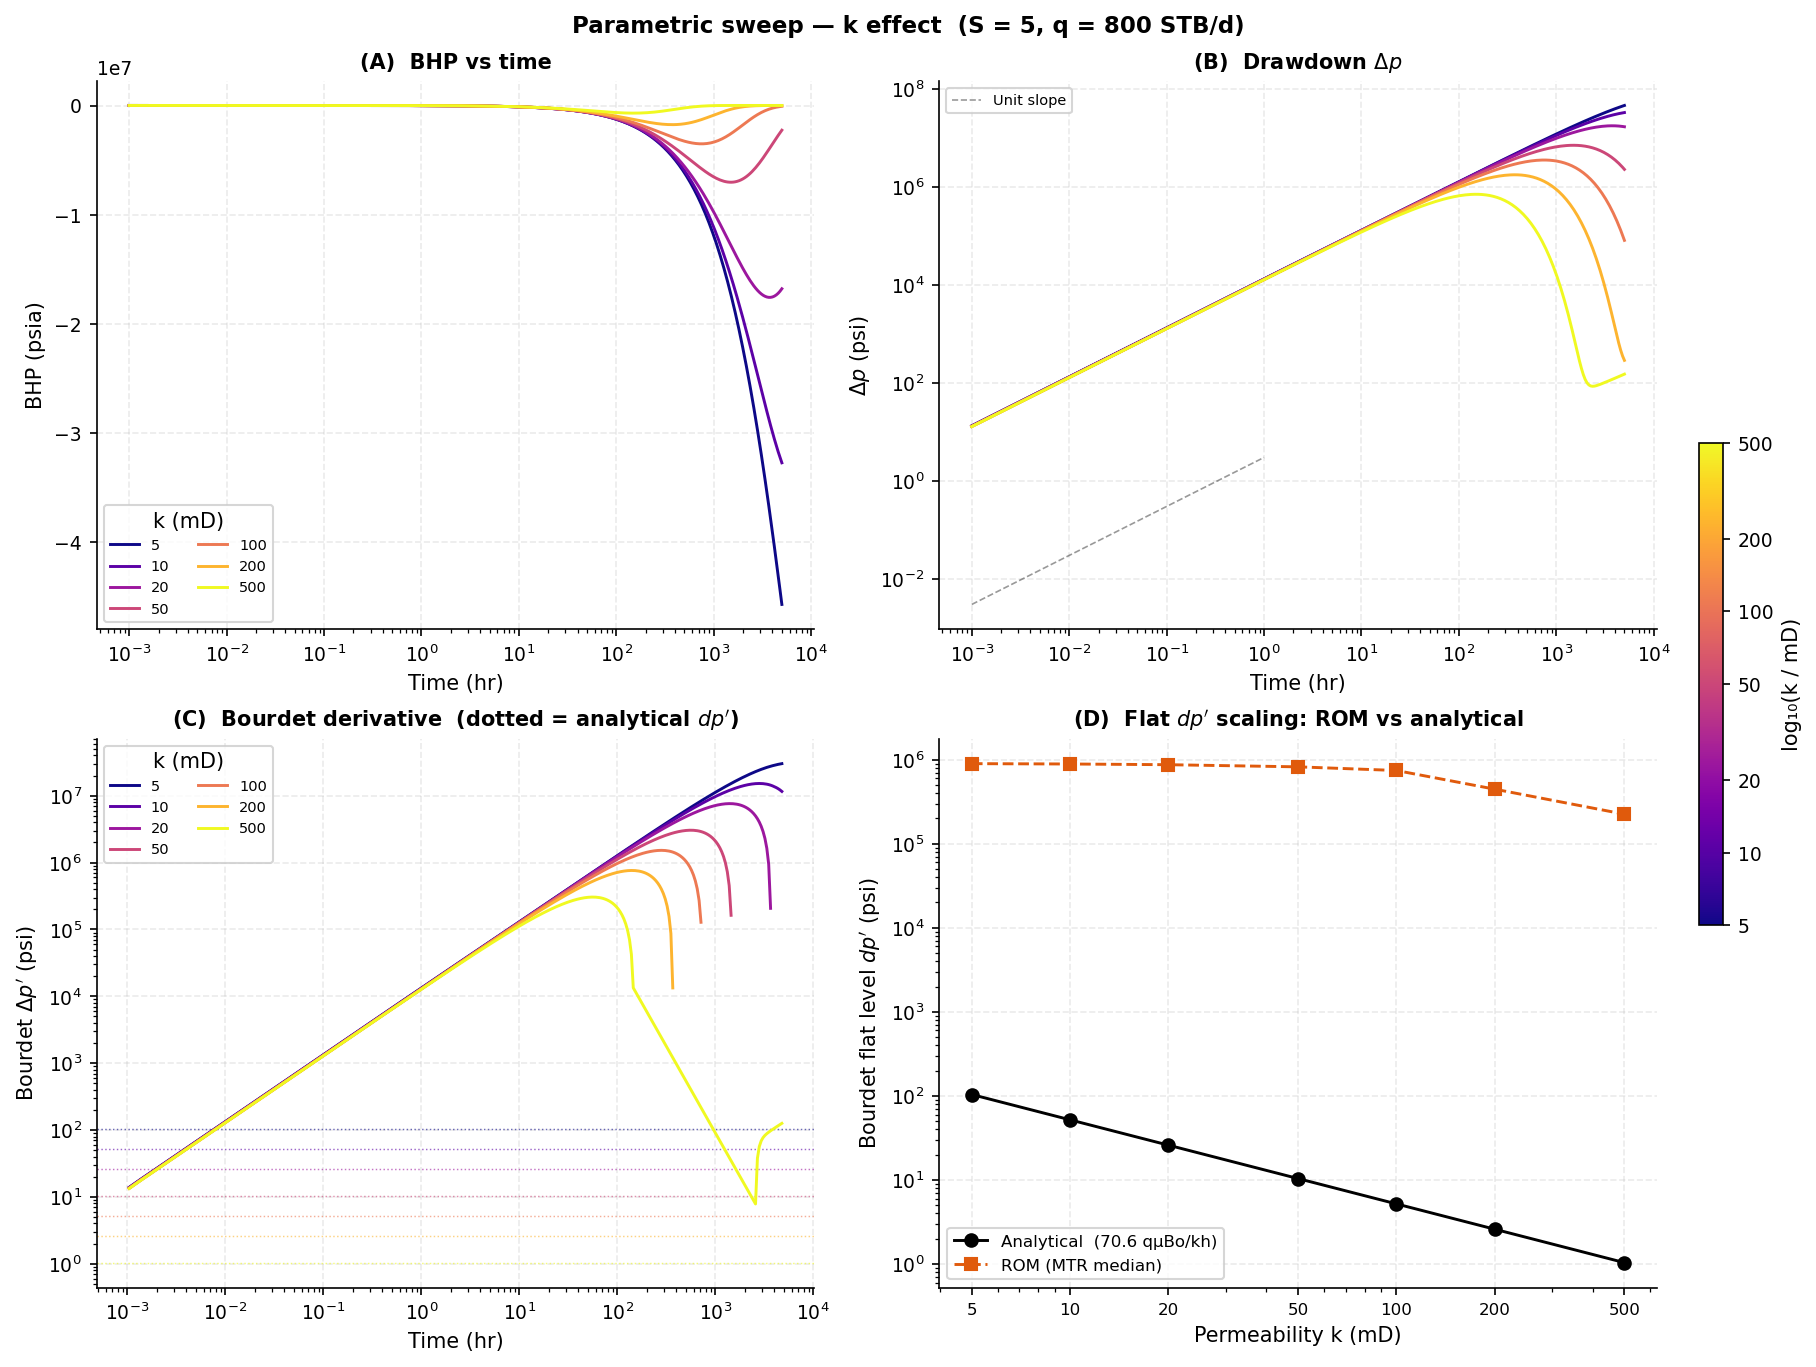

Figure saved.


In [6]:
k_sweep  = [5, 10, 20, 50, 100, 200, 500]
S_fixed  = 5
q_const  = [(0, 800)]

cmap_sweep = plt.cm.plasma
colors_k   = [cmap_sweep(i / (len(k_sweep) - 1)) for i in range(len(k_sweep))]

sweep_results = {}
t_start_sw = time.perf_counter()
for k_v in k_sweep:
    sweep_results[k_v] = predict(k_v, S_fixed, q_const)
total_ms = (time.perf_counter() - t_start_sw) * 1000
print(f'{len(k_sweep)} predictions in {total_ms:.0f} ms  ({total_ms/len(k_sweep):.1f} ms each)')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Panel A — BHP
ax_A = axes[0, 0]
for k_v, col in zip(k_sweep, colors_k):
    res = sweep_results[k_v]
    ax_A.semilogx(res['t_hr'], res['bhp_psia'], lw=1.4, color=col, label=f'{k_v}')
ax_A.set_xlabel('Time (hr)')
ax_A.set_ylabel('BHP (psia)')
ax_A.set_title('(A)  BHP vs time')
ax_A.legend(title='k (mD)', fontsize=7, ncol=2,
            loc='lower left', framealpha=0.8)

# Panel B — Drawdown log-log
ax_B = axes[0, 1]
for k_v, col in zip(k_sweep, colors_k):
    res = sweep_results[k_v]
    dp_plot = np.clip(res['dp_psi'], 0.1, None)
    ax_B.loglog(res['t_hr'], dp_plot, lw=1.4, color=col)
# Unit slope reference
t_ref = np.array([0.001, 1])
ax_B.loglog(t_ref, t_ref * 3, 'k--', lw=0.8, alpha=0.4, label='Unit slope')
ax_B.set_xlabel('Time (hr)')
ax_B.set_ylabel(r'$\Delta p$ (psi)')
ax_B.set_title(r'(B)  Drawdown $\Delta p$')
ax_B.legend(fontsize=7)

# Panel C — Bourdet derivative (separate subplot per k for clarity)
ax_C = axes[1, 0]
for k_v, col in zip(k_sweep, colors_k):
    res  = sweep_results[k_v]
    dp_c = np.clip(res['dp_psi'], 0.1, None)
    tc, dpc, bdc = bourdet_derivative(res['t_hr'], dp_c)
    ax_C.loglog(tc, bdc, lw=1.4, color=col, label=f'{k_v}')
    # Analytical flat level
    dp_an = 70.6 * 800 * 1.2 * 1.15 / (k_v * 150)
    ax_C.axhline(dp_an, color=col, ls=':', lw=0.7, alpha=0.6)
ax_C.set_xlabel('Time (hr)')
ax_C.set_ylabel(r"Bourdet $\Delta p'$ (psi)")
ax_C.set_title(r"(C)  Bourdet derivative  (dotted = analytical $dp'$)")
ax_C.legend(title='k (mD)', fontsize=7, ncol=2, framealpha=0.8)

# Panel D — analytical dp' vs k with ROM flat-level estimate
ax_D = axes[1, 1]
dp_analytical = [70.6 * 800 * 1.2 * 1.15 / (k_v * 150) for k_v in k_sweep]
dp_rom_flat   = []
for k_v in k_sweep:
    res  = sweep_results[k_v]
    dp_c = np.clip(res['dp_psi'], 0.1, None)
    tc, dpc, bdc = bourdet_derivative(res['t_hr'], dp_c)
    # MTR window estimate: median Bourdet value between t=10 and t=500 hr
    mtr_mask = (tc >= 10) & (tc <= 500)
    dp_rom_flat.append(float(np.median(bdc[mtr_mask])) if mtr_mask.sum() > 3 else np.nan)

ax_D.loglog(k_sweep, dp_analytical, 'k-o', lw=1.4, ms=6,
            label='Analytical  (70.6 qμBo/kh)')
ax_D.loglog(k_sweep, dp_rom_flat,   's--', lw=1.4, ms=6,
            color='#e05a0c', label='ROM (MTR median)')
ax_D.set_xlabel('Permeability k (mD)')
ax_D.set_ylabel(r"Bourdet flat level $dp'$ (psi)")
ax_D.set_title(r"(D)  Flat $dp'$ scaling: ROM vs analytical")
ax_D.legend(fontsize=8)
ax_D.set_xticks(k_sweep)
ax_D.set_xticklabels(k_sweep, fontsize=8)

# Shared colorbar for k panels A, B, C
sm  = ScalarMappable(cmap=cmap_sweep,
                     norm=Normalize(vmin=np.log10(5), vmax=np.log10(500)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, 1], shrink=0.4, pad=0.04,
                    label='log₁₀(k / mD)', location='right')
cbar.set_ticks([np.log10(v) for v in k_sweep])
cbar.set_ticklabels([str(v) for v in k_sweep])

fig.suptitle(f'Parametric sweep — k effect  (S = {S_fixed}, q = 800 STB/d)',
             fontsize=11, fontweight='bold')
plt.savefig(RESULTS_DIR / 'parametric_sweep_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 6. Parametric sweep — effect of skin

Six S values at fixed k = 50 mD, constant 800 STB/d.

**Expected behaviour:**
- Increasing S shifts the BHP curve downward by a constant skin pressure drop $\Delta p_s = 0.869\,m\,S$
- The Bourdet derivative flat level is **independent of S** — skin does not affect $dp'$
- WBS end time extends with S because the skin-to-wellbore transition is delayed

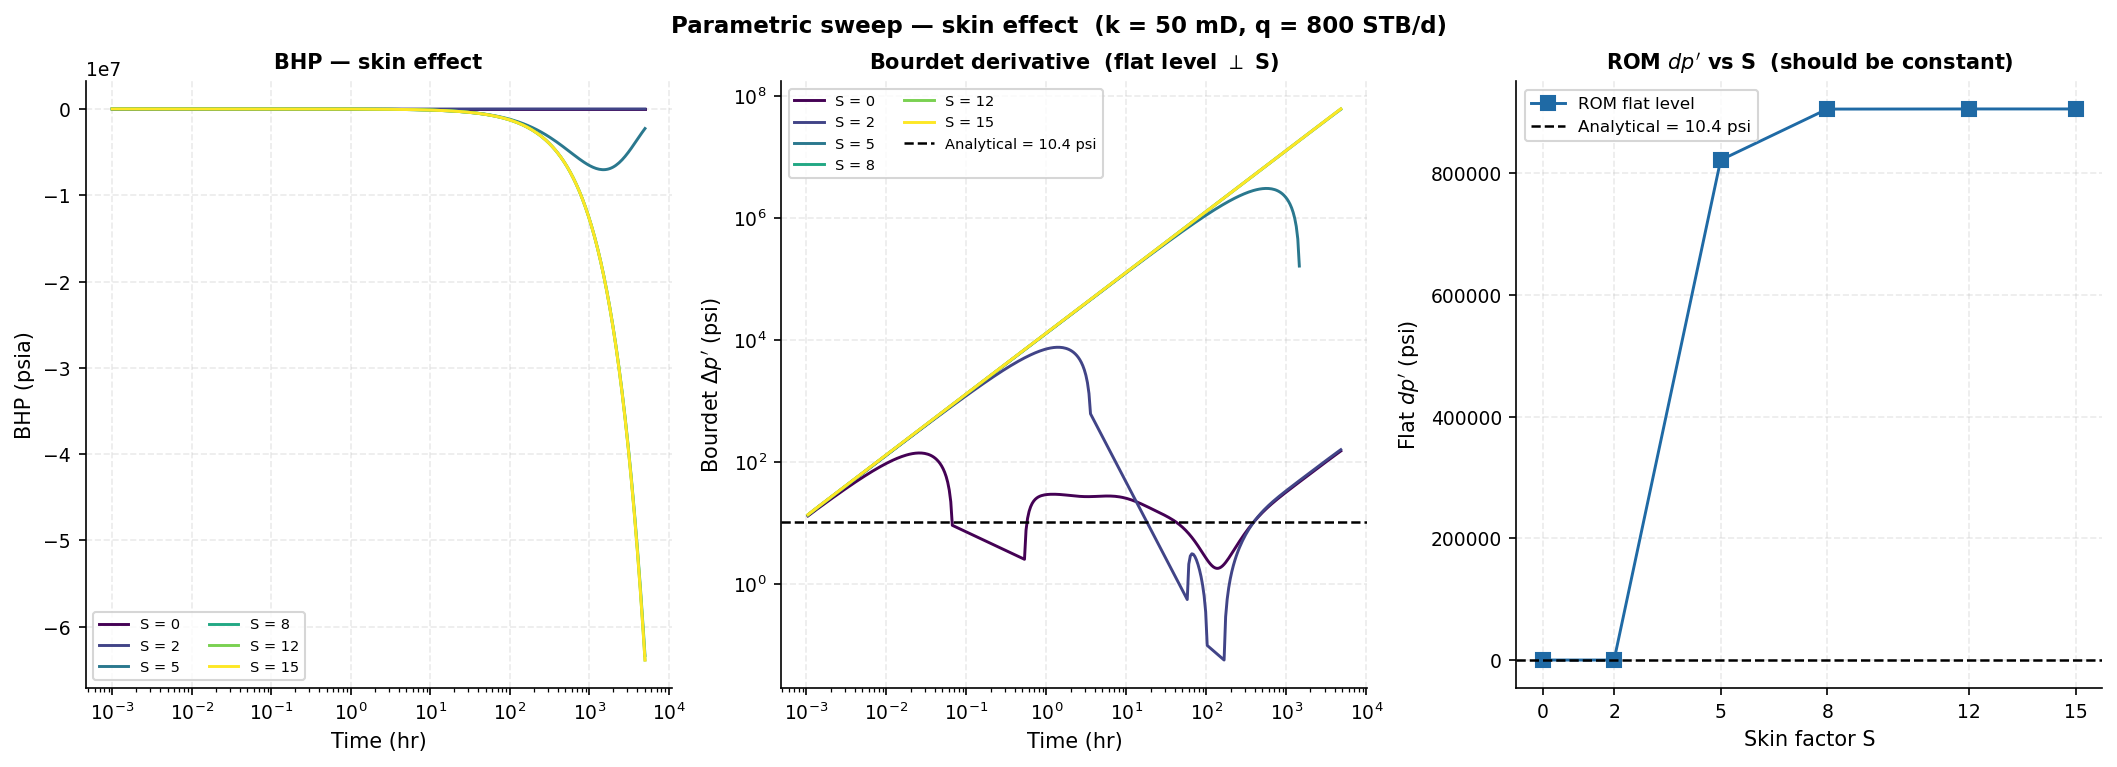

Figure saved.


In [7]:
S_sweep  = [0, 2, 5, 8, 12, 15]
k_fixed  = 50
q_const2 = [(0, 800)]

cmap_s   = plt.cm.viridis
colors_s = [cmap_s(i / (len(S_sweep) - 1)) for i in range(len(S_sweep))]

sweep_s = {}
for s_v in S_sweep:
    sweep_s[s_v] = predict(k_fixed, s_v, q_const2)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# BHP
for s_v, col in zip(S_sweep, colors_s):
    res = sweep_s[s_v]
    axes[0].semilogx(res['t_hr'], res['bhp_psia'], lw=1.4,
                     color=col, label=f'S = {s_v}')
axes[0].set_xlabel('Time (hr)')
axes[0].set_ylabel('BHP (psia)')
axes[0].set_title('BHP — skin effect')
axes[0].legend(fontsize=7, ncol=2)

# Bourdet derivative
dp_flat_s = []
for s_v, col in zip(S_sweep, colors_s):
    res  = sweep_s[s_v]
    dp_c = np.clip(res['dp_psi'], 0.1, None)
    ts, dps, bds = bourdet_derivative(res['t_hr'], dp_c)
    axes[1].loglog(ts, bds, lw=1.4, color=col, label=f'S = {s_v}')
    mtr_m = (ts >= 10) & (ts <= 500)
    dp_flat_s.append(float(np.median(bds[mtr_m])) if mtr_m.sum() > 3 else np.nan)

dp_prime_k50 = 70.6 * 800 * 1.2 * 1.15 / (50 * 150)
axes[1].axhline(dp_prime_k50, color='k', ls='--', lw=1.2,
                label=f"Analytical = {dp_prime_k50:.1f} psi")
axes[1].set_xlabel('Time (hr)')
axes[1].set_ylabel(r"Bourdet $\Delta p'$ (psi)")
axes[1].set_title(r"Bourdet derivative  (flat level $\perp$ S)")
axes[1].legend(fontsize=7, ncol=2)

# Flat dp' vs S
axes[2].plot(S_sweep, dp_flat_s, 's-', color='#1f6aa5', ms=7, lw=1.4,
             label='ROM flat level')
axes[2].axhline(dp_prime_k50, color='k', ls='--', lw=1.2,
                label=f'Analytical = {dp_prime_k50:.1f} psi')
axes[2].set_xlabel('Skin factor S')
axes[2].set_ylabel(r"Flat $dp'$ (psi)")
axes[2].set_title(r"ROM $dp'$ vs S  (should be constant)")
axes[2].legend(fontsize=8)
axes[2].set_xticks(S_sweep)

fig.suptitle(f'Parametric sweep — skin effect  (k = {k_fixed} mD, q = 800 STB/d)',
             fontsize=11, fontweight='bold')
plt.savefig(RESULTS_DIR / 'parametric_sweep_S.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 7. Save prediction results

In [8]:
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
pred_name = f'k{k_query:03d}_s{S_query:02d}_{timestamp}'
pred_dir  = RESULTS_DIR / pred_name
pred_dir.mkdir(parents=True, exist_ok=True)

np.save(pred_dir / 't_hr.npy',     r2['t_hr'])
np.save(pred_dir / 'bhp_psia.npy', r2['bhp_psia'])
np.save(pred_dir / 'dp_psi.npy',   r2['dp_psi'])
np.save(pred_dir / 'p_field.npy',  r2['p_field'])
np.save(pred_dir / 'q_vec.npy',    r2['q_vec'])

query_log = dict(
    timestamp     = timestamp,
    k_mD          = k_query,
    S_skin        = S_query,
    rate_schedule = rate_schedule,
    stable        = r2['stable'],
    stabilised    = r2['stabilised'],
    wall_ms       = r2['wall_ms'],
    n_modes       = int(n),
    bhp_min_psia  = float(r2['bhp_psia'].min()),
    bhp_max_psia  = float(r2['bhp_psia'].max()),
)
with open(pred_dir / 'query_log.json', 'w') as f:
    json.dump(query_log, f, indent=2)

print(f'Saved to : {pred_dir}')
print(f't_hr     : {r2["t_hr"].shape}')
print(f'bhp_psia : {r2["bhp_psia"].shape}')
print(f'p_field  : {r2["p_field"].shape}')
print(f'wall time: {r2["wall_ms"]:.1f} ms')

Saved to : ..\results\predictions\k075_s03_20260423_134232
t_hr     : (350,)
bhp_psia : (350,)
p_field  : (2500, 350)
wall time: 5.5 ms
